In [2]:
%pip install pandas numpy openpyxl


Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl (10.8 MB)
     |████████████████████████████████| 250 kB 289 kB/s eta 0:00:01
     |████████████████████████████████| 508 kB 905 kB/s eta 0:00:01
     |████████████████████████████████| 348 kB 1.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [23]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.1 MB 1.1 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 1.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [10]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Paths
DATA_PATH = PROJECT_ROOT / "data" / "GICRE_features_target.xlsx"
MODEL_PATH = PROJECT_ROOT / "models" / "stage2_production.joblib"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: /Users/khushi/Desktop/Stock-Market-Prediction
Dataset: /Users/khushi/Desktop/Stock-Market-Prediction/data/GICRE_features_target.xlsx
Dataset exists: True


In [11]:
import pandas as pd
import numpy as np

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (190427, 22)

Columns:
['datetime', 'volatility_kcw', 'trend_ema_fast', 'fib_618', 'volatility_kcc', 'fib_236', 'volatility_bbm', 'Supertrend', 'close', 'volume_vwap', 'trend_psar_up', 'volatility_bbh', 'volatility_kcl', 'trend_psar_down', 'trend_ichimoku_b', 'trend_visual_ichimoku_b', 'momentum_kama', 'volatility_dch', 'volatility_kch', 'trend_sma_slow', 'volatility_dcm', 'target_correction']


,datetime,volatility_kcw,trend_ema_fast,fib_618,volatility_kcc,fib_236,volatility_bbm,Supertrend,close,volume_vwap,...,volatility_kcl,trend_psar_down,trend_ichimoku_b,trend_visual_ichimoku_b,momentum_kama,volatility_dch,volatility_kch,trend_sma_slow,volatility_dcm,target_correction
0,2015-02-02 09:15:00+05:30,1.351992,140.650000,0.0,140.533333,0.0,140.650000,0.0,140.65,140.533333,...,139.583333,140.950,140.475,312.785646,140.650000,140.95,141.483333,140.650000,140.475,1
1,2015-02-02 09:20:00+05:30,1.603611,140.526923,0.0,140.308333,0.0,140.250000,0.0,139.85,140.335747,...,139.183333,140.950,140.250,312.785646,140.291353,140.95,141.433333,140.250000,140.250,0
2,2015-02-02 09:25:00+05:30,1.425460,140.515089,0.0,140.305556,0.0,140.316667,0.0,140.45,140.328156,...,139.305556,140.950,140.250,312.785646,140.361465,140.95,141.305556,140.316667,140.250,0
3,2015-02-02 09:30:00+05:30,1.228961,140.520460,0.0,140.362500,0.0,140.375000,0.0,140.55,140.346476,...,139.500000,140.928,140.250,312.785646,140.444977,140.95,141.225000,140.375000,140.250,0
4,2015-02-02 09:35:00+05:30,1.196354,140.517312,0.0,140.426667,0.0,140.400000,0.0,140.50,140.421043,...,139.586667,140.928,140.350,312.785646,140.469302,141.15,141.266667,140.400000,140.350,0


In [12]:
# ==========================================
# DATASET AUDIT
# ==========================================

print("Total rows:", len(df))
print("Total columns:", len(df.columns))

print("\nColumn details:")
for i, col in enumerate(df.columns):
    print(f"{i:02d} | {col} | dtype={df[col].dtype}")

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget statistics:")
print(df["close"].describe())

Total rows: 190427
Total columns: 22

Column details:
00 | datetime | dtype=object
01 | volatility_kcw | dtype=float64
02 | trend_ema_fast | dtype=float64
03 | fib_618 | dtype=float64
04 | volatility_kcc | dtype=float64
05 | fib_236 | dtype=float64
06 | volatility_bbm | dtype=float64
07 | Supertrend | dtype=float64
08 | close | dtype=float64
09 | volume_vwap | dtype=float64
10 | trend_psar_up | dtype=float64
11 | volatility_bbh | dtype=float64
12 | volatility_kcl | dtype=float64
13 | trend_psar_down | dtype=float64
14 | trend_ichimoku_b | dtype=float64
15 | trend_visual_ichimoku_b | dtype=float64
16 | momentum_kama | dtype=float64
17 | volatility_dch | dtype=float64
18 | volatility_kch | dtype=float64
19 | trend_sma_slow | dtype=float64
20 | volatility_dcm | dtype=float64
21 | target_correction | dtype=int64

Missing values:
datetime                   0
volatility_kcw             0
trend_ema_fast             0
fib_618                    0
volatility_kcc             0
fib_236           

In [13]:
# ==========================================
# COMPACT DATA QUALITY CHECK
# ==========================================

print("=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== MISSING VALUES ===")
missing = df.isna().sum()
print(missing[missing > 0])

print("\nTotal missing values:", int(df.isna().sum().sum()))

print("\n=== DUPLICATES ===")
print("Duplicate rows:", int(df.duplicated().sum()))

print("\n=== DATETIME ===")
print("First:", df["datetime"].iloc[0])
print("Last :", df["datetime"].iloc[-1])

print("\n=== CLOSE ===")
print("Min :", df["close"].min())
print("Max :", df["close"].max())
print("NaN :", df["close"].isna().sum())

=== COLUMNS ===
['datetime', 'volatility_kcw', 'trend_ema_fast', 'fib_618', 'volatility_kcc', 'fib_236', 'volatility_bbm', 'Supertrend', 'close', 'volume_vwap', 'trend_psar_up', 'volatility_bbh', 'volatility_kcl', 'trend_psar_down', 'trend_ichimoku_b', 'trend_visual_ichimoku_b', 'momentum_kama', 'volatility_dch', 'volatility_kch', 'trend_sma_slow', 'volatility_dcm', 'target_correction']

=== MISSING VALUES ===
Series([], dtype: int64)

Total missing values: 0

=== DUPLICATES ===
Duplicate rows: 0

=== DATETIME ===
First: 2015-02-02 09:15:00+05:30
Last : 2025-05-23 15:25:00+05:30

=== CLOSE ===
Min : 59.3
Max : 764.2
NaN : 0


In [14]:
# ==========================================
# TIME SERIES ORDER CHECK
# ==========================================

# Convert datetime to proper datetime type
df["datetime"] = pd.to_datetime(df["datetime"])

print("=== DATETIME ORDER CHECK ===")

print("Already sorted:",
      df["datetime"].is_monotonic_increasing)

print("Duplicate timestamps:",
      int(df["datetime"].duplicated().sum()))

print("\nRows:", len(df))
print("First:", df["datetime"].iloc[0])
print("Last :", df["datetime"].iloc[-1])

# Check for backwards jumps
time_diff = df["datetime"].diff().dropna()

print("\nNegative time jumps:",
      int((time_diff < pd.Timedelta(0)).sum()))

print("Zero time gaps:",
      int((time_diff == pd.Timedelta(0)).sum()))

print("\nLargest time gap:")
print(time_diff.max())

=== DATETIME ORDER CHECK ===
Already sorted: True
Duplicate timestamps: 0

Rows: 190427
First: 2015-02-02 09:15:00+05:30
Last : 2025-05-23 15:25:00+05:30

Negative time jumps: 0
Zero time gaps: 0

Largest time gap:
4 days 17:50:00


In [15]:
# ==========================================
# FEATURE INVENTORY
# ==========================================

TARGET_COL = "close"
TIME_COL = "datetime"

feature_cols = [
    c for c in df.columns
    if c not in [TIME_COL, TARGET_COL]
]

print("Number of features:", len(feature_cols))

print("\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:02d}. {col}")

Number of features: 20

Feature columns:
01. volatility_kcw
02. trend_ema_fast
03. fib_618
04. volatility_kcc
05. fib_236
06. volatility_bbm
07. Supertrend
08. volume_vwap
09. trend_psar_up
10. volatility_bbh
11. volatility_kcl
12. trend_psar_down
13. trend_ichimoku_b
14. trend_visual_ichimoku_b
15. momentum_kama
16. volatility_dch
17. volatility_kch
18. trend_sma_slow
19. volatility_dcm
20. target_correction


In [16]:
# ==========================================
# SUSPICIOUS FEATURE / TARGET RELATIONSHIP
# ==========================================

print("=== CLOSE vs SUSPICIOUS FEATURES ===")

suspicious_cols = [
    "target_correction",
    "trend_ichimoku_b"
]

for col in suspicious_cols:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print("dtype:", df[col].dtype)
        print("min :", df[col].min())
        print("max :", df[col].max())
        print("mean:", df[col].mean())
        print("corr with close:", df[col].corr(df["close"]))

print("\n=== LAST 10 ROWS ===")

cols_to_show = [
    "datetime",
    "close",
    "target_correction",
    "trend_ichimoku_b"
]

print(df[cols_to_show].tail(10).to_string(index=False))

=== CLOSE vs SUSPICIOUS FEATURES ===

--- target_correction ---
dtype: int64
min : 0
max : 1
mean: 0.3067527188896533
corr with close: -0.01941343525573505

--- trend_ichimoku_b ---
dtype: float64
min : 60.375
max : 761.325
mean: 312.78564594306476
corr with close: 0.9998281104493114

=== LAST 10 ROWS ===
                 datetime  close  target_correction  trend_ichimoku_b
2025-05-23 14:40:00+05:30 653.00                  0           650.575
2025-05-23 14:45:00+05:30 652.50                  0           650.875
2025-05-23 14:50:00+05:30 649.65                  0           650.875
2025-05-23 14:55:00+05:30 650.50                  0           651.625
2025-05-23 15:00:00+05:30 649.95                  0           651.850
2025-05-23 15:05:00+05:30 649.90                  0           652.050
2025-05-23 15:10:00+05:30 649.55                  0           652.050
2025-05-23 15:15:00+05:30 649.25                  0           652.050
2025-05-23 15:20:00+05:30 650.50                  0           6

## Supervised Learning Window Construction

The time-series data is converted into supervised learning samples using a
30-step lookback window and a 4-step forecasting horizon.

- Lookback window: 30 time steps
- Input features: 21
- Forecast horizon: 4 future closing prices
- Input shape: `(samples, 30, 21)`
- Target shape: `(samples, 4)`

The 21 input features consist of the historical closing price and the
pre-engineered numerical features provided as part of the project dataset.

In [17]:
import numpy as np
import pandas as pd

close_col = "close"
horizon = 4
lookback = 30
stride = 1

# Create future targets t+1..t+4
for k in range(1, horizon+1):
    df[f"{close_col}_t+{k}"] = df[close_col].shift(-k)

future_cols = [f"{close_col}_t+{k}" for k in range(1, horizon+1)]
df_supervised = df.dropna(subset=future_cols).reset_index(drop=True)

# Numeric features
numeric_cols = df_supervised.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in numeric_cols if c not in future_cols]

values  = df_supervised[feature_cols].values.astype(np.float32)
targets = df_supervised[future_cols].values.astype(np.float32)
last_close_series = df_supervised[close_col].values.astype(np.float32)

# Sliding windows
X_list, y_list, last_close_list = [], [], []
for i in range(0, len(df_supervised)-lookback, stride):
    X_list.append(values[i:i+lookback])
    y_list.append(targets[i+lookback-1])
    last_close_list.append(last_close_series[i+lookback-1])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)
last_close = np.array(last_close_list, dtype=np.float32)

print("✅ Data windows:", X.shape, y.shape)


✅ Data windows: (190393, 30, 21) (190393, 4)


In [18]:
from sklearn.preprocessing import MinMaxScaler

N = len(X)
train_end = int(N * 0.7)
val_end   = int(N * 0.85)

# Fit scaler ONLY on training portion (to avoid data leakage)
feat_scaler = MinMaxScaler()
tgt_scaler  = MinMaxScaler()

feat_scaler.fit(X[:train_end].reshape(-1, X.shape[-1]))
tgt_scaler.fit(y[:train_end])

# Transform
X_scaled = feat_scaler.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
y_scaled = tgt_scaler.transform(y)

# Split
X_train, y_train = X_scaled[:train_end], y_scaled[:train_end]
X_val,   y_val   = X_scaled[train_end:val_end], y_scaled[train_end:val_end]
X_test,  y_test  = X_scaled[val_end:], y_scaled[val_end:]

print("No-leak scaling done.")


No-leak scaling done.


In [19]:
import torch
import torch.nn as nn

class HybridLSTMGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.gru  = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size*2, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        gru_out, _  = self.gru(x)
        combined = torch.cat((lstm_out[:,-1,:], gru_out[:,-1,:]), dim=1)
        return self.fc(combined)


In [35]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

model = HybridLSTMGRU(
    input_size=X_train.shape[2],
    hidden_size=64,
    num_layers=2,
    output_size=y_train.shape[1],
    dropout=0.2
).to(device)

print("Model device:", next(model.parameters()).device)

Using device: mps
Model device: mps:0


In [21]:
import torch.utils.data as data

train_ds = data.TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

val_ds = data.TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

train_dl = data.DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True
)

val_dl = data.DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False
)

print("Train samples:", len(train_ds))
print("Validation samples:", len(val_ds))

Train samples: 133275
Validation samples: 28559


In [22]:
from copy import deepcopy

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # ✅ add this

num_epochs = 10
patience = 5
best_val_loss = float('inf')
wait = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

best_model_state = None
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    batch_losses = []

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
        val_loss = np.mean([
            criterion(model(xb.to(device)), yb.to(device)).item()
            for xb, yb in val_dl
        ])

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"📉 LR reduced: {old_lr:.6f} → {new_lr:.6f}")

    print(f"Epoch {epoch+1}/{num_epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {new_lr:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"⛔ Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
print(f"✅ Best Val Loss: {best_val_loss:.6f}")


Epoch 1/10 | Train: 0.000354 | Val: 0.000261 | LR: 0.001000
Epoch 2/10 | Train: 0.000049 | Val: 0.000266 | LR: 0.001000
Epoch 3/10 | Train: 0.000039 | Val: 0.000046 | LR: 0.001000
Epoch 4/10 | Train: 0.000034 | Val: 0.000081 | LR: 0.001000
Epoch 5/10 | Train: 0.000030 | Val: 0.000032 | LR: 0.001000
Epoch 6/10 | Train: 0.000029 | Val: 0.000038 | LR: 0.001000
Epoch 7/10 | Train: 0.000024 | Val: 0.000054 | LR: 0.001000
Epoch 8/10 | Train: 0.000020 | Val: 0.000024 | LR: 0.001000
Epoch 9/10 | Train: 0.000018 | Val: 0.000124 | LR: 0.001000
Epoch 10/10 | Train: 0.000017 | Val: 0.000027 | LR: 0.001000
✅ Best Val Loss: 0.000024


In [23]:
torch.save({
    "model_state": model.state_dict(),
    "features": feature_cols,
    "seq_len": 30,
    "pred_len": 4,
    "hidden_size": 128,
    "num_layers": 2,
    "dropout": 0.2,
    "best_val_loss": best_val_loss,
    "train_losses": train_losses,
    "val_losses": val_losses,
}, "hybrid_lstm_gru_model.pt")

In [24]:
import joblib

joblib.dump(feat_scaler, "feature_scaler.joblib")
joblib.dump(tgt_scaler, "target_scaler.joblib")

['target_scaler.joblib']

In [25]:
print("model:", "model" in globals())
print("X_train:", "X_train" in globals())
print("y_train:", "y_train" in globals())
print("best_model_state:", "best_model_state" in globals())
print("df:", "df" in globals())
print("tgt_scaler:", "tgt_scaler" in globals())

model: True
X_train: True
y_train: True
best_model_state: True
df: True
tgt_scaler: True


In [26]:
model.eval()
with torch.no_grad():
    y_pred_scaled = []
    for i in range(len(X_test)):
        x = torch.tensor(X_test[i:i+1]).to(device)
        pred = model(x).cpu().numpy()
        y_pred_scaled.append(pred[0])

y_pred_scaled = np.array(y_pred_scaled)


In [27]:
y_pred = tgt_scaler.inverse_transform(y_pred_scaled)
y_true = tgt_scaler.inverse_transform(y_test)


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print(f"✅ Test MSE:  {mse:.6f}")
print(f"✅ Test RMSE: {rmse:.6f}")
print(f"✅ Test MAE:  {mae:.6f}")


✅ Test MSE:  275.809387
✅ Test RMSE: 16.607510
✅ Test MAE:  10.550097


In [29]:
last_close_test = last_close[val_end:]  # ensure aligned

correct = 0
total = len(y_true)

for i in range(total):
    pred_next = y_pred[i][0]  # predicted t+1 close
    true_next = y_true[i][0]  # actual t+1 close
    prev_close = last_close_test[i]

    pred_dir = np.sign(pred_next - prev_close)
    true_dir = np.sign(true_next - prev_close)

    if pred_dir == true_dir:
        correct += 1

directional_accuracy = correct / total * 100
print(f"✅ Directional Accuracy: {directional_accuracy:.2f}%")


✅ Directional Accuracy: 49.49%


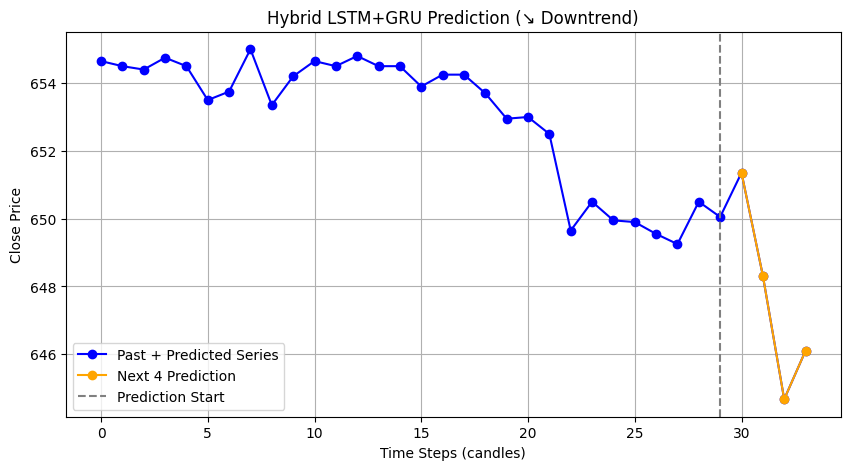

Predicted next 4 closes: [651.354 648.318 644.673 646.102]
Pattern: ↘ Downtrend


In [30]:
import matplotlib.pyplot as plt

# Get latest window and predict
x_last = torch.tensor(X_scaled[-1:]).to(device)
model.eval()
with torch.no_grad():
    y_pred_scaled = model(x_last).cpu().numpy()

future_4 = tgt_scaler.inverse_transform(y_pred_scaled)[0]
past_30 = df[close_col].values[-lookback:]

# Continuous price series (past + predicted)
full_series = np.concatenate([past_30, future_4])

# Pattern detection
if future_4[1] > future_4[0] and future_4[1] > future_4[2]:
    pattern = "🔺 Local Peak"
elif future_4[1] < future_4[0] and future_4[1] < future_4[2]:
    pattern = "🔻 Local Valley"
elif future_4[-1] > future_4[0]:
    pattern = "↗ Uptrend"
else:
    pattern = "↘ Downtrend"

# Plotting
plt.figure(figsize=(10,5))
plt.plot(full_series, marker='o', color="blue", label="Past + Predicted Series")

# Highlight predicted portion in orange
plt.plot(range(lookback, lookback+horizon), future_4, color="orange", marker='o', label="Next 4 Prediction")

plt.axvline(x=lookback-1, color='gray', linestyle='--', label="Prediction Start")
plt.title(f"Hybrid LSTM+GRU Prediction ({pattern})")
plt.xlabel("Time Steps (candles)")
plt.ylabel("Close Price")
plt.grid(True)
plt.legend()
plt.show()

print("Predicted next 4 closes:", np.round(future_4, 3))
print("Pattern:", pattern)


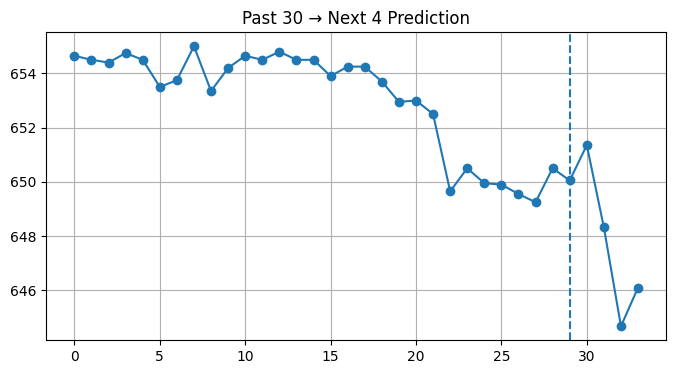

Pred: [651.354 648.318 644.673 646.102]


In [31]:
# Predict last window
x_last = torch.tensor(X_scaled[-1:]).to(device)
with torch.no_grad():
    future_scaled = model(x_last).cpu().numpy()

future = tgt_scaler.inverse_transform(future_scaled)[0]
past = df[close_col].values[-lookback:]
series = np.concatenate([past, future])

plt.figure(figsize=(8,4))
plt.plot(series, marker='o')
plt.axvline(x=lookback-1, linestyle='--')
plt.title("Past 30 → Next 4 Prediction")
plt.grid(); plt.show()

print("Pred:", np.round(future,3))


In [32]:
import joblib

stage2_path = "../stage2_production.joblib"

bundle = joblib.load(stage2_path)

print("Bundle loaded successfully!")
print("Keys:", bundle.keys())

Bundle loaded successfully!
Keys: dict_keys(['scaler', 'features', 'seq_len', 'pred_len', 'model_state', 'model_params'])


In [ ]:
# ============================================================
# Stage-2 (5m) Correction Forecasting — Pipeline-Compatible
# Produces: stage2_production.joblib for your FastAPI pipeline
# ============================================================

import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# Config
# -----------------------------
INPUT_XLSX   = "GICRE_features_target.xlsx"
CLOSE_COL    = "close"
LOOKBACK     = 30
HORIZON      = 4
STRIDE       = 1
BATCH_SIZE   = 128
LR           = 1e-3
EPOCHS       = 50
PATIENCE     = 6
HIDDEN       = 128
NUM_LAYERS   = 2
DROPOUT      = 0.2
SAVE_PATH    = "stage2_production.joblib"   # <-- FINAL BUNDLE PATH

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Data
# -----------------------------
df = pd.read_excel(INPUT_XLSX)

# Create future targets t+1..t+4
future_cols = [f"{CLOSE_COL}_t+{k}" for k in range(1, HORIZON + 1)]
for k in range(1, HORIZON + 1):
    df[f"{CLOSE_COL}_t+{k}"] = df[CLOSE_COL].shift(-k)

df_supervised = df.dropna(subset=future_cols).reset_index(drop=True)

# numeric feature columns (excluding targets)
numeric_cols  = df_supervised.select_dtypes(include=[np.number]).columns.tolist()
feature_cols  = [c for c in numeric_cols if c not in future_cols]

values   = df_supervised[feature_cols].values.astype(np.float32)
targets  = df_supervised[future_cols].values.astype(np.float32)
last_cl  = df_supervised[CLOSE_COL].values.astype(np.float32)

# Sliding windows (X: [N, LOOKBACK, F], y: [N, HORIZON])
X_list, y_list, last_close_list = [], [], []
for i in range(0, len(df_supervised) - LOOKBACK, STRIDE):
    X_list.append(values[i:i+LOOKBACK])
    y_list.append(targets[i+LOOKBACK-1])
    last_close_list.append(last_cl[i+LOOKBACK-1])

X = np.array(X_list, dtype=np.float32)   # [N, L, F]
y = np.array(y_list, dtype=np.float32)   # [N, H]
last_close = np.array(last_close_list, dtype=np.float32)

print(f"✅ Data windows: X{X.shape}, y{y.shape}")

# -----------------------------
# Scaling
# -----------------------------
feat_scaler = StandardScaler()
N = len(X)
train_end = int(N * 0.7)
val_end   = int(N * 0.85)

# fit on training portion only (avoid leakage)
feat_scaler.fit(X[:train_end].reshape(-1, X.shape[-1]))

# transform X
X_scaled = feat_scaler.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)

# scale y (future close values) using the SAME 'close' column stats from feat_scaler
close_idx = feature_cols.index(CLOSE_COL)  # must exist
close_mean = float(feat_scaler.mean_[close_idx])
close_std  = float(feat_scaler.scale_[close_idx])
y_scaled = (y - close_mean) / (close_std + 1e-12)

# splits
X_train, y_train = X_scaled[:train_end], y_scaled[:train_end]
X_val,   y_val   = X_scaled[train_end:val_end], y_scaled[train_end:val_end]
X_test,  y_test  = X_scaled[val_end:], y_scaled[val_end:]
last_close_test  = last_close[val_end:]

train_dl = DataLoader(TensorDataset(
    torch.tensor(X_train), torch.tensor(y_train)
), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

val_dl = DataLoader(TensorDataset(
    torch.tensor(X_val), torch.tensor(y_val)
), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

test_dl = DataLoader(TensorDataset(
    torch.tensor(X_test), torch.tensor(y_test)
), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# -----------------------------
# Model
# -----------------------------
class HybridLSTMGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.gru  = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size*2, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # [B, L, H]
        gru_out,  _ = self.gru(x)   # [B, L, H]
        last = torch.cat((lstm_out[:, -1, :], gru_out[:, -1, :]), dim=1)  # [B, 2H]
        return self.fc(last)  # [B, HORIZON]

model = HybridLSTMGRU(
    input_size=X.shape[-1],
    hidden_size=HIDDEN,
    num_layers=NUM_LAYERS,
    output_size=HORIZON,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# -----------------------------
# Train with early stopping
# -----------------------------
best_val = float('inf')
best_state = None
wait = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    train_losses = []

    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE, dtype=torch.float32), yb.to(DEVICE, dtype=torch.float32)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_losses = []
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE, dtype=torch.float32), yb.to(DEVICE, dtype=torch.float32)
            vloss = criterion(model(xb), yb).item()
            val_losses.append(vloss)

    tr = float(np.mean(train_losses)) if train_losses else 0.0
    va = float(np.mean(val_losses)) if val_losses else tr

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(va)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != old_lr:
        print(f"📉 LR: {old_lr:.6f} → {new_lr:.6f}")

    print(f"Epoch {epoch:03d}/{EPOCHS} | Train {tr:.6f} | Val {va:.6f}")

    if va < best_val:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"⛔ Early stopping at epoch {epoch}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# -----------------------------
# Evaluate (invert close scaling)
# -----------------------------
model.eval()
with torch.no_grad():
    preds_scaled = []
    for xb, _ in test_dl:
        xb = xb.to(DEVICE, dtype=torch.float32)
        preds_scaled.append(model(xb).cpu().numpy())
    preds_scaled = np.vstack(preds_scaled)

preds = preds_scaled * (close_std + 1e-12) + close_mean
true  = y_test       * (close_std + 1e-12) + close_mean

mse  = mean_squared_error(true, preds)
rmse = float(np.sqrt(mse))
mae  = mean_absolute_error(true, preds)
print(f"✅ Test MSE:  {mse:.6f}")
print(f"✅ Test RMSE: {rmse:.6f}")
print(f"✅ Test MAE:  {mae:.6f}")

# Directional Accuracy (t+1)
sign_match = np.sign(preds[:,0] - last_close_test) == np.sign(true[:,0] - last_close_test)
dir_acc = 100.0 * float(np.mean(sign_match))
print(f"✅ Directional Accuracy (t+1): {dir_acc:.2f}%")

# -----------------------------
# SAVE: Pipeline-compatible bundle
# -----------------------------
bundle = {
    "scaler": feat_scaler,              # single StandardScaler for input features
    "features": feature_cols,           # must include 'close'
    "seq_len": LOOKBACK,
    "pred_len": HORIZON,
    "model_state": {k: v.cpu() for k, v in model.state_dict().items()},
    "model_params": {
        "arch": "HybridLSTMGRU",        # <--- important tag so API rebuilds the right model
        "n_features": X.shape[-1],
        "hidden": HIDDEN,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "pred_len": HORIZON
    }
}

# Use default protocol for max compatibility; compress to reduce size
joblib.dump(bundle, SAVE_PATH, compress=3)
print(f"🎉 Saved Stage-2 bundle → {SAVE_PATH}")


✅ Data windows: X(190393, 30, 21), y(190393, 4)
Epoch 001/50 | Train 0.005382 | Val 0.001237
Epoch 002/50 | Train 0.000584 | Val 0.000638
Epoch 003/50 | Train 0.000474 | Val 0.000748
Epoch 004/50 | Train 0.000448 | Val 0.000507
Epoch 005/50 | Train 0.000371 | Val 0.001263
Epoch 006/50 | Train 0.000354 | Val 0.000628
Epoch 007/50 | Train 0.000326 | Val 0.000450
Epoch 008/50 | Train 0.000294 | Val 0.002071
Epoch 009/50 | Train 0.000290 | Val 0.001408
Epoch 010/50 | Train 0.000252 | Val 0.000375
Epoch 011/50 | Train 0.000247 | Val 0.000783
Epoch 012/50 | Train 0.000243 | Val 0.000268
Epoch 013/50 | Train 0.000213 | Val 0.000239
Epoch 014/50 | Train 0.000236 | Val 0.000839
Epoch 015/50 | Train 0.000208 | Val 0.000254
📉 LR: 0.001000 → 0.000500
Epoch 016/50 | Train 0.000201 | Val 0.000309
Epoch 017/50 | Train 0.000141 | Val 0.000293
Epoch 018/50 | Train 0.000144 | Val 0.000245
Epoch 019/50 | Train 0.000146 | Val 0.000226
Epoch 020/50 | Train 0.000141 | Val 0.000618


In [33]:
import joblib
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler

# -------- Safe Loader (same as pipeline) --------
class SafeUnpickler(pickle.Unpickler):
    CLASS_MAP = {
        "StandardScalerProxy": StandardScaler,
        "sklearn.preprocessing._data.StandardScalerProxy": StandardScaler,
    }

    def find_class(self, module, name):
        full = f"{module}.{name}"
        if name in self.CLASS_MAP:
            return self.CLASS_MAP[name]
        if full in self.CLASS_MAP:
            return self.CLASS_MAP[full]
        return super().find_class(module, name)

def safe_joblib_load(path):
    try:
        return joblib.load(path)
    except:
        with open(path, "rb") as f:
            return SafeUnpickler(f).load()


# -------- Load the joblib --------
path = path = "../stage2_production.joblib"
raw = safe_joblib_load(path)

print("\n✅ JOBLIB LOADED\n")

print("🔑 Available keys:", list(raw.keys()))

if "features" in raw:
    print("\n✅ FEATURES:", raw["features"])

if "scaler" in raw:
    sc = raw["scaler"]
    print("\n✅ SCALER TYPE:", type(sc))
    print("Scaler mean length:", len(sc.mean_))
    print("Scaler scale length:", len(sc.scale_))

if "model_params" in raw:
    print("\n✅ MODEL PARAMS:", raw["model_params"])

    if "arch" in raw["model_params"]:
        print("✅ ARCHITECTURE TAG:", raw["model_params"]["arch"])
    else:
        print("⚠️ No 'arch' tag; fallback to LSTMSeq unless detected")

if "model_state" in raw:
    ms = raw["model_state"]
    print("\n✅ MODEL STATE DICT ENTRIES:", len(ms))
    print("Sample keys:", list(ms.keys())[:10])



✅ JOBLIB LOADED

🔑 Available keys: ['scaler', 'features', 'seq_len', 'pred_len', 'model_state', 'model_params']

✅ FEATURES: ['volatility_kcw', 'trend_ema_fast', 'fib_618', 'volatility_kcc', 'fib_236', 'volatility_bbm', 'Supertrend', 'close', 'volume_vwap', 'trend_psar_up', 'volatility_bbh', 'volatility_kcl', 'trend_psar_down', 'trend_ichimoku_b', 'trend_visual_ichimoku_b', 'momentum_kama', 'volatility_dch', 'volatility_kch', 'trend_sma_slow', 'volatility_dcm', 'target_correction']

✅ SCALER TYPE: <class 'sklearn.preprocessing._data.StandardScaler'>
Scaler mean length: 21
Scaler scale length: 21

✅ MODEL PARAMS: {'arch': 'HybridLSTMGRU', 'n_features': 21, 'hidden': 128, 'num_layers': 2, 'dropout': 0.2, 'pred_len': 4}
✅ ARCHITECTURE TAG: HybridLSTMGRU

✅ MODEL STATE DICT ENTRIES: 18
Sample keys: ['lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'gru.weight_ih_l0', 'gru.weight_

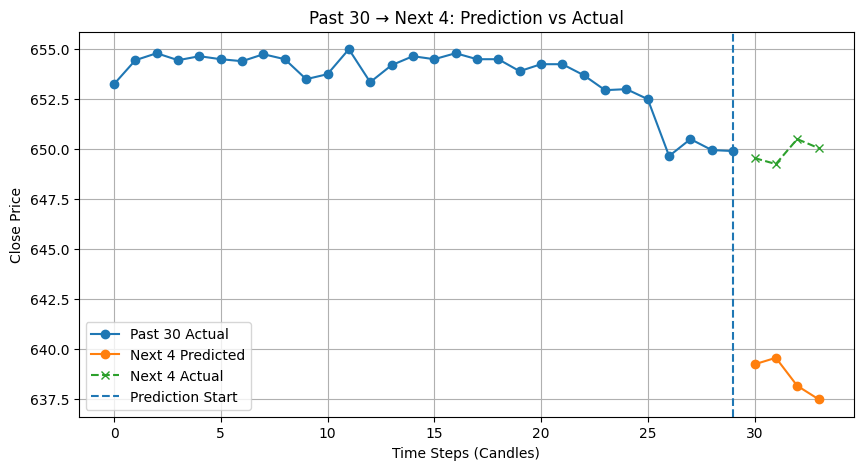

Predicted next 4: [639.219 639.547 638.146 637.472]
Actual next 4   : [649.55 649.25 650.5  650.05]


In [38]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ---------- BASIC CONFIG ----------
seq = raw["seq_len"]
future = raw["pred_len"]
scaler = raw["scaler"]
feature_cols = raw["features"]

# ---------- LOAD ORIGINAL DATA ----------
INPUT_XLSX = "../data/GICRE_features_target.xlsx"
df = pd.read_excel(INPUT_XLSX)

# ---------- REBUILD MODEL FROM SAVED JOBLIB ----------
model_params = raw["model_params"]

model = HybridLSTMGRU(
    input_size=model_params["n_features"],
    hidden_size=model_params["hidden"],
    num_layers=model_params["num_layers"],
    output_size=model_params["pred_len"],
    dropout=model_params["dropout"]
).to(device)

model.load_state_dict(raw["model_state"])
model.eval()

# ---------- EXTRACT LAST 30 + ACTUAL NEXT 4 ----------
df_tail = df.tail(seq + future)

past_30_actual = df_tail["close"].values[:seq]
actual_next_4 = df_tail["close"].values[seq:]

# ---------- PREPARE INPUT WINDOW ----------
last_window = df_tail[feature_cols].values[:seq]

X_last = scaler.transform(last_window).astype(np.float32)
X_last = torch.tensor(X_last).unsqueeze(0).to(device)

# ---------- PREDICT NEXT 4 CLOSES ----------
with torch.no_grad():
    pred_scaled = model(X_last).cpu().numpy()

# ---------- INVERSE SCALE CLOSE ----------
close_idx = feature_cols.index("close")
close_mean = float(scaler.mean_[close_idx])
close_std = float(scaler.scale_[close_idx])

pred_next_4 = pred_scaled * close_std + close_mean
pred_next_4 = pred_next_4.flatten()

# ---------- PLOT ----------
timeline = np.arange(seq + future)

plt.figure(figsize=(10,5))

plt.plot(
    timeline[:seq],
    past_30_actual,
    label="Past 30 Actual",
    marker="o"
)

plt.plot(
    timeline[seq:],
    pred_next_4,
    label="Next 4 Predicted",
    marker="o"
)

plt.plot(
    timeline[seq:],
    actual_next_4,
    label="Next 4 Actual",
    linestyle="--",
    marker="x"
)

plt.axvline(
    x=seq-1,
    linestyle="--",
    label="Prediction Start"
)

plt.title("Past 30 → Next 4: Prediction vs Actual")
plt.xlabel("Time Steps (Candles)")
plt.ylabel("Close Price")
plt.grid(True)
plt.legend()
plt.show()

print("Predicted next 4:", np.round(pred_next_4, 3))
print("Actual next 4   :", np.round(actual_next_4, 3))

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -------- BASIC CONFIG --------
seq = raw["seq_len"]        # 30
future = raw["pred_len"]    # 4
scaler = raw["scaler"]
feature_cols = raw["features"]

# -------- Extract last 30 + actual next 4 from df --------
df_tail = df.tail(seq + future)
past_30_actual = df_tail["close"].values[:seq]
actual_next_4  = df_tail["close"].values[seq:]

# -------- Prepare input window --------
last_window = df_tail[feature_cols].values[:seq]
X_last = scaler.transform(last_window).astype(np.float32)
X_last = torch.tensor(X_last).unsqueeze(0).to(DEVICE)

# -------- Predict next 4 closes --------
model.eval()
with torch.no_grad():
    pred_scaled = model(X_last).cpu().numpy()

# -------- Inverse scale (for close only) --------
close_idx = feature_cols.index("close")
close_mean = float(scaler.mean_[close_idx])
close_std  = float(scaler.scale_[close_idx])

pred_next_4 = pred_scaled * close_std + close_mean
pred_next_4 = pred_next_4.flatten()

# -------- Plot --------
timeline = np.arange(seq + future)

plt.figure(figsize=(10,5))

# past actual
plt.plot(timeline[:seq], past_30_actual, label="Past 30 Actual", color="blue", marker="o")

# predicted
plt.plot(timeline[seq:], pred_next_4, label="Next 4 Predicted", color="orange", marker="o")

# true future
plt.plot(timeline[seq:], actual_next_4, label="Next 4 Actual", color="green", linestyle="--", marker="x")

plt.axvline(x=seq-1, linestyle='--', color="gray", label="Prediction Start")
plt.title("📈 Past 30 → Next 4: Prediction vs Actual")
plt.xlabel("Time Steps (Candles)")
plt.ylabel("Close Price")
plt.grid(True)
plt.legend()
plt.show()

print("Predicted next 4:", np.round(pred_next_4, 3))
print("Actual next 4   :", np.round(actual_next_4, 3))


NameError: name 'df' is not defined

In [44]:
%pip install graphviz

from graphviz import Digraph

g = Digraph('model_flow', format='png')
g.attr(rankdir='LR', size='10,3')

# Style
node_style = {'shape':'box', 'style':'rounded,filled', 'color':'lightblue', 'fontsize':'12'}

# Nodes
g.node('A', 'Raw OHLCV\n(Open, High, Low, Close, Volume)', **node_style)
g.node('B', 'Feature Engineering\n(Indicators: EMA, VWAP,\nSupertrend, PSAR, Ichimoku...)', **node_style)
g.node('C', 'Sliding Window\n(Past 30 candles)', **node_style)
g.node('D', 'Standard Scaler\n(fit only on train)', **node_style)
g.node('E', 'Tensor Shape\n30 × 21 features', **node_style)
g.node('F', 'Hybrid LSTM + GRU\n2 layers each, 128 units\nDropout = 0.2', **node_style)
g.node('G', 'Prediction\nNext 4 Close Prices', **node_style)

# Arrows
g.edge('A', 'B')
g.edge('B', 'C')
g.edge('C', 'D')
g.edge('D', 'E')
g.edge('E', 'F')
g.edge('F', 'G')

g.render('../images/lstm_gru_pipeline_diagram', view=True)

# Save & render
#g.render('../images/lstm_gru_pipeline_diagram', view=True)

print("✅ Pipeline diagram saved as lstm_gru_pipeline_diagram.png")


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
✅ Pipeline diagram saved as lstm_gru_pipeline_diagram.png
